# **Capstone Project: [Deteksi Penyakit pada Tanaman Kelapa Sawit]**
**ID Group:** LAI25-RM112

**Anggota Kelompok:**
- A200YBF418_Refanda Surya Saputra - A200YBF418@devacademy.id
- A270YAF435_Risky Fahriza - A270YAF435@devacademy.id
- A528YBF449_Sebastian Luth Hasibuan - A528YBF449@devacademy.id
- A184YBF450_Sefza Auma Alam - A184YBF450@devacademy.id

## **Import Libraries/Packages**

In [39]:
import os
import random
import shutil
import warnings
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf
from keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback, ReduceLROnPlateau
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import TFSMLayer, Input, Flatten, Rescaling
from tensorflow.keras.callbacks import Callback
from tensorflow.saved_model import save
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.losses import BinaryCrossentropy

from PIL import Image
from skimage import io
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.transform import rotate, AffineTransform, warp
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

from tqdm.notebook import tqdm as tq

import gdown
from google.colab import drive
from IPython.display import FileLink

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2.18.0


## **Loading Data**

### **Preparation Data**

#### **Using Google Colab**

In [ ]:
# Mounting dari google drive
drive.mount('/content/drive')

# Mengakses dataset di google drive
dataset_path = '/content/drive/My Drive/Capstone LAI25-RM112/Dataset/palm-disease-dataset.zip'

# Ekstrak dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_file:
    zip_file.extractall('/content/dataset')

#### **Using Local Device**

In [ ]:
# Ketika menggunakan IDE lokal
file_id = "1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, 'palm-disease-dataset.zip', quiet=False)

# Unzip berkas yang telah diuduh dari google drive
with zipfile.ZipFile('palm-disease-dataset.zip', 'r') as zip_file:
    zip_file.extractall()

#### **Using Kaggle Notebook**

In [3]:
# Ketika menggunakan Kaggle Notebook
kaggle_input_path = '/kaggle/input/palm-oil-disease-dataset/palm-disease-dataset'

kaggle_output_path = '/kaggle/working/palm-disease-dataset'

if not os.path.exists(kaggle_output_path):
    os.makedirs(kaggle_output_path)

try:
    shutil.copytree(kaggle_input_path, kaggle_output_path, dirs_exist_ok=True)
    print(f"Berhasil menyalin dataset dari '{kaggle_input_path}' ke {kaggle_output_path}")
except Exception as e:
    print(f"Unexpected error: {e}")

Berhasil menyalin dataset dari '/kaggle/input/palm-oil-disease-dataset/palm-disease-dataset' ke /kaggle/working/palm-disease-dataset


### **Checking Dataset**

In [4]:
# Mengecek label pada dataset

# Ketika menggunakan kaggle, hapus komentar pada baris kode di bawah ini
palm_disease_path = "/kaggle/working/palm-disease-dataset"

# Ketika menggunakan google colab atau lokal device hapus komentar pada baris kode di bawah ini
#palm_disease_path = "/dataset/palm-disease-dataset"

# Menyimpan label
list_label = os.listdir(palm_disease_path)

# Menampilkan list label
list_label

['Magnesium Deficiency', 'Healthy', 'Fungal Disease', 'Scale Insect']

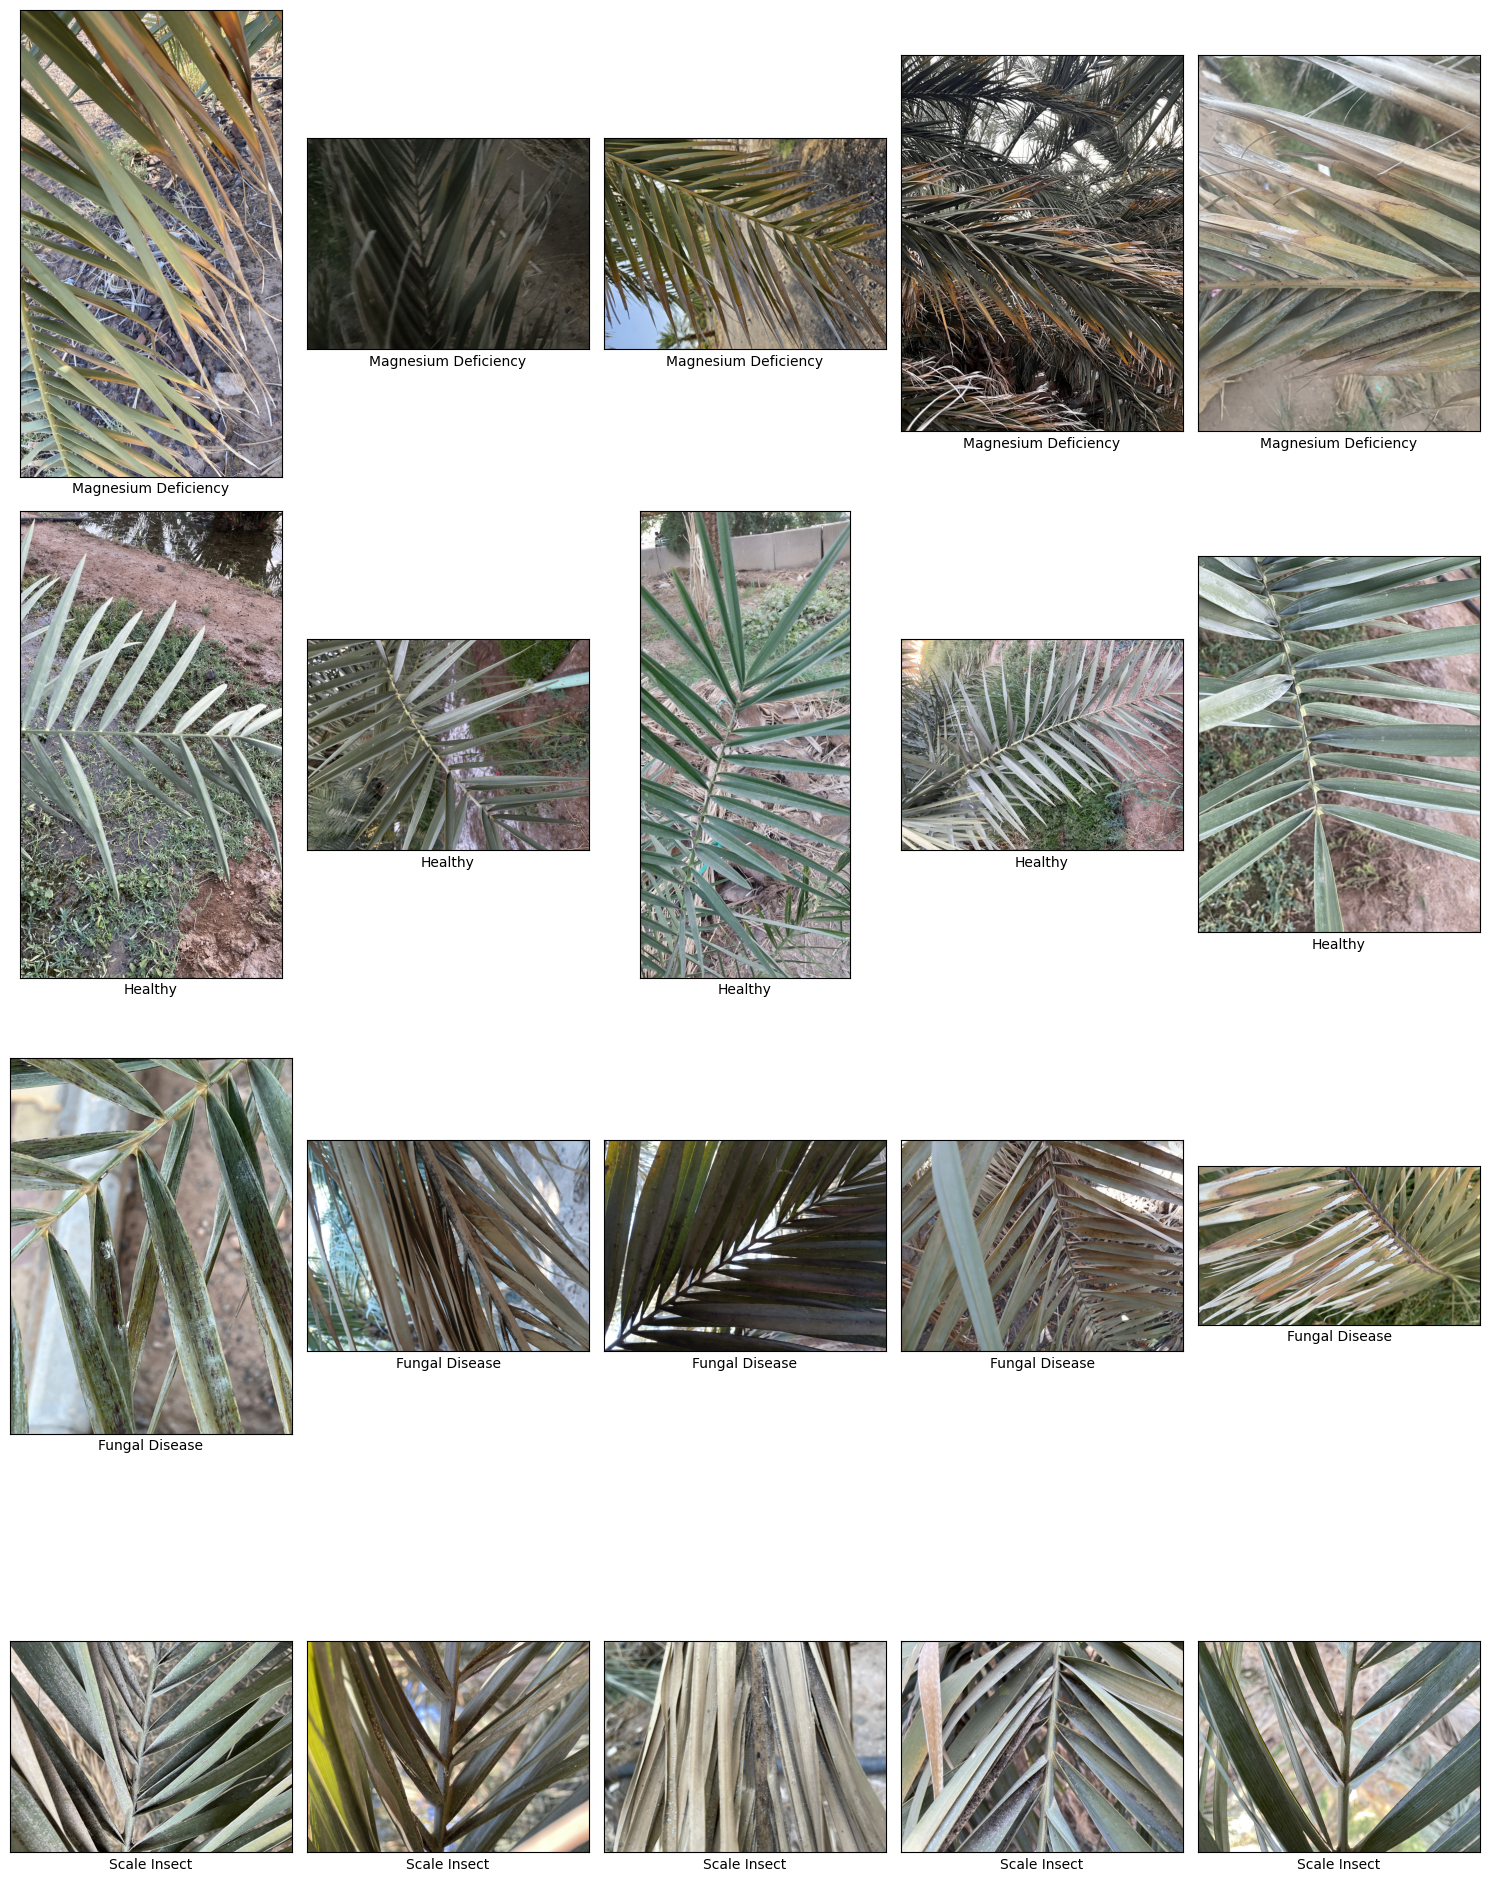

In [5]:
# Membuat dictionary untuk menyimpan gambar untuk setiap kelas dalam data
palm_disease_image = {}

# Menentukan path sumber dataset

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = "/kaggle/working/palm-disease-dataset/"

# Hapus komentar pada kode ini jika menggunakan lokal device atau Google Colab
#source_path = "/dataset/palm-disease-dataset/"

for i in os.listdir(source_path):
  palm_disease_image[i]  = os.listdir(source_path + i)

# menampilkan secara acak 5 gambar untuk masing-masing kelas
fig, ax = plt.subplots(4, 5, figsize=(15, 20))

for i, label in enumerate(os.listdir(source_path)):
  images = np.random.choice(palm_disease_image[label], 5, replace=False)
  for j, image in enumerate(images):
    img_path = os.path.join(source_path, label, image)
    img = Image.open(img_path)
    ax[i, j].imshow(img)
    ax[i, j].set(xlabel=label, xticks=[], yticks=[])

fig.tight_layout()

In [6]:
# Membuat fungsi untuk melihat jumlah image tiap-tiap kelas
def get_image_count(path):
  image_count = {}
  for label in os.listdir(path):
    image_count[label] = len(os.listdir(os.path.join(path, label)))
  return image_count

print(get_image_count(source_path))

{'Healthy': 41, 'Scale Insect': 80, 'Magnesium Deficiency': 55, 'Fungal Disease': 53}


### **Distribution Plot of Class Dataset**

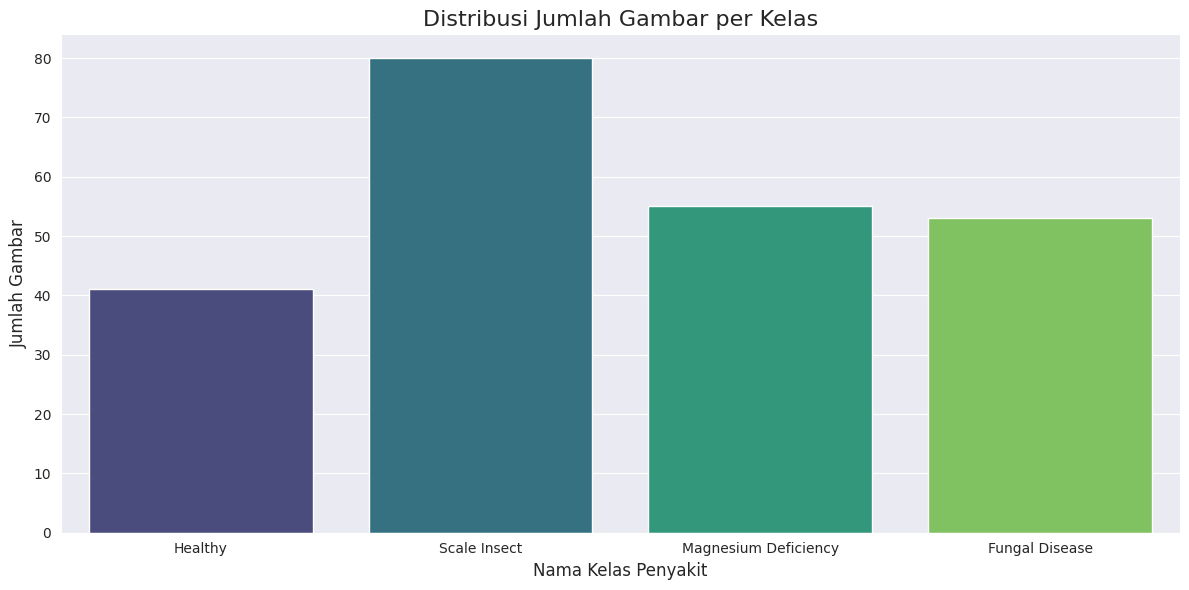

In [7]:
def plot_distribution(path):
  # Membuat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
  file_name = []
  labels = []
  full_path = []

  # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
  for path, subdirs, files in os.walk(path):
    for name in files:
      file_name.append(name)
      labels.append(path.split('/')[-1])
      full_path.append(os.path.join(path, name))

  distribution_train = pd.DataFrame({
      'path': full_path,
      'file_name': file_name,
      'labels': labels
  })
  for name in files:
      file_name.append(name)
      labels.append(path.split('/')[-1])

  # Plot distribusi gambar setiap kelas
  plt.figure(figsize=(12, 6))
  sns.set_style('darkgrid')
  sns.countplot(data=distribution_train, x='labels', palette='viridis')
    
  plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=16)
  plt.xlabel("Nama Kelas Penyakit", fontsize=12)
  plt.ylabel("Jumlah Gambar", fontsize=12)
  plt.tight_layout() 
  plt.show()

plot_distribution(source_path)

## **Preprocessing Data**


### **Augmentation Data**

In [8]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  angle = random.randint(0, 180)
  return rotate(img, angle)

# Membuat fungsi untuk melakukan rotasi searah jarum ram
def clockwise_rotation(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  angle = random.randint(0, 180)
  return rotate(img, -angle)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  img = adjust_gamma(img, gamma=0.5, gain=1)
  return img

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  return np.flipud(img)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(shear=0.2)
  shear_img = warp(img, transform, mode='wrap')
  return shear_img

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(translation=(0, 40))
  warp_img = warp(img, transform, mode='wrap')
  return warp_img

In [9]:
# Membuat varabel transofrmasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'add_brightness': add_brightness,
    'flip_up_down': flip_up_down,
    'shear_image': sheared,
    'warp_shift': warp_shift
}

def generate_augmented_image(image_class_name, source_image_path, num_augmented_images):
  img_processed_path = os.path.join(source_image_path, image_class_name)

  processed_images = []

  for img in os.listdir(img_processed_path):
    processed_images.append(os.path.join(img_processed_path, img))

  images_to_generate = num_augmented_images - len(os.listdir(img_processed_path))

  i = 1

  while i <= images_to_generate:
    random_image = random.choice(processed_images)

    try:
      original_image = io.imread(random_image)
      transformed_image = None

      num_transformations_to_apply = random.randint(1, len(transformations))

      num_transformations = 0

      while num_transformations <= num_transformations_to_apply:
        key = random.choice(list(transformations))
        transformed_image = transformations[key](original_image)
        num_transformations += 1

      new_image_path = "%s/augmented_image_%s.jpg" % (img_processed_path, i)
      transformed_image = img_as_ubyte(transformed_image)
      cv2.imwrite(new_image_path, transformed_image)
      i += 1
    except Exception as e:
      print('Could not read the', image, ':', e, 'hence skipping it.')

In [10]:
source_path = '/kaggle/working/palm-disease-dataset/'

for label in list_label:
  generate_augmented_image(label, source_path, 500)

print("Berhasil melakukan augmentasi gambar")

Berhasil melakukan augmentasi gambar


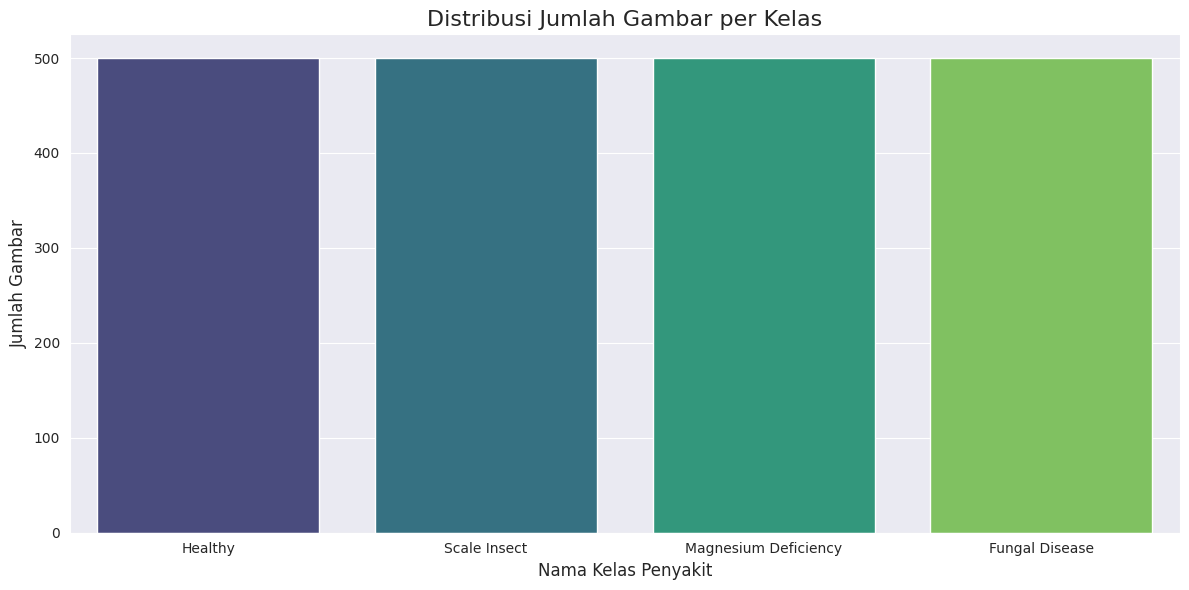

In [11]:
# Melihat plot distribusi kelas setelah dilakukan augmentasi
plot_distribution(source_path)

### **Spliting Data**

In [6]:
# Membuat variabel untuk menampung lokasi folder dari dataset gambar

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#source_path = '/dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = '/kaggle/working/palm-disease-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(source_path):
  for name in files:
    file_name.append(name)
    labels.append(path.split('/')[-1])
    full_path.append(os.path.join(path, name))

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
image_df = pd.DataFrame({
    'file_name': file_name,
    'labels': labels,
    'full_path': full_path
})

# Melihat jumlah data gambar pada masing-masing label
image_df['labels'].value_counts()

labels
Scale Insect            80
Magnesium Deficiency    55
Fungal Disease          53
Healthy                 41
Name: count, dtype: int64

In [7]:
# variabel yang digunaka pada pemisahan data ini, di mana variabel x = data path dan y = data labels
X = image_df['full_path']
y = image_df['labels']

# Split dataset awal menjadi data train dan temp (test dan validasi)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Menyatukan ke dalam maisng-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_validation = pd.DataFrame({
    'path': X_val,
    'labels': y_val,
    'set': 'validation'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_validation, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set         labels              
test        Fungal Disease           8
            Healthy                  6
            Magnesium Deficiency     9
            Scale Insect            12
train       Fungal Disease          37
            Healthy                 29
            Magnesium Deficiency    38
            Scale Insect            56
validation  Fungal Disease           8
            Healthy                  6
            Magnesium Deficiency     8
            Scale Insect            12
dtype: int64


In [8]:
# Mengecek sampel data
print(df_all.sample(5))

                                                  path        labels    set
31   /kaggle/working/palm-disease-dataset/Scale Ins...  Scale Insect  train
111  /kaggle/working/palm-disease-dataset/Healthy/H...       Healthy  train
55   /kaggle/working/palm-disease-dataset/Healthy/I...       Healthy  train
35   /kaggle/working/palm-disease-dataset/Healthy/H...       Healthy  train
39   /kaggle/working/palm-disease-dataset/Scale Ins...  Scale Insect  train


In [9]:
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#datasource_path = 'dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
datasource_path = '/kaggle/working/palm-disease-dataset/'

# Membuat variabel dataset, tempat menampung data yang telah dilakukan splitting

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#dataset_path = 'dataset/final-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
dataset_path = '/kaggle/working/final-dataset/'

for index, row in tq(df_all.iterrows()):
  file_path = row['path']

  if os.path.exists(file_path) == False:
    file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

  # Membuat direktori tujuan folder
  if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
    os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

  # Menentukan tujuan file
  destination_file_name = file_path.split('/')[-1]
  destination_path = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

  # Memindahkan file ke direktori tujuan
  if os.path.exists(destination_path) == False:
    shutil.copy2(file_path, destination_path)

0it [00:00, ?it/s]

### **Image Data Generator**

In [10]:
# Mendefinisikan direktori daset training, test, dan validation

# Hapus komentar pada kode di bawah ini jika menggunakan Google Colab atau device lokal
# TRAIN_DIR = "dataset/final-dataset/train"
# TEST_DIR = "dataset/final-dataset/test"
# VAL_DIR = "dataset/final-dataset/validation"

# Hapus komentar pada kode di bawah ini jika menggunakan Kaggle Notebook
TRAIN_DIR = '/kaggle/working/final-dataset/train'
TEST_DIR = '/kaggle/working/final-dataset/test'
VAL_DIR = '/kaggle/working/final-dataset/validation'

# Membuat fungsi untuk menampilkan jumlah data train berdasarkan label
def print_total_train_data(label):
  train_temp = os.path.join(TRAIN_DIR, label)
  train_count = len(os.listdir(train_temp))
  print("Total train data for {} is {}".format(label, train_count))

# Membuat fungsi untuk menampilkan jumlah data test berdasarkan label
def print_total_test_data(label):
  test_temp = os.path.join(TEST_DIR, label)
  test_count = len(os.listdir(test_temp))
  print("Total test data for {} is {}".format(label, test_count))

# Membuat fungsi untuk menampilkan jumlah data validation berdasarkan label
def print_total_validation_data(label):
  val_temp = os.path.join(VAL_DIR, label)
  val_count = len(os.listdir(val_temp))
  print("Total validation data for {} is {}".format(label, val_count))

for label in list_label:
  print_total_train_data(label)
  print_total_test_data(label)
  print_total_validation_data(label)
  print("\n")

Total train data for Magnesium Deficiency is 38
Total test data for Magnesium Deficiency is 9
Total validation data for Magnesium Deficiency is 8


Total train data for Healthy is 29
Total test data for Healthy is 6
Total validation data for Healthy is 6


Total train data for Fungal Disease is 37
Total test data for Fungal Disease is 8
Total validation data for Fungal Disease is 8


Total train data for Scale Insect is 56
Total test data for Scale Insect is 12
Total validation data for Scale Insect is 12




In [36]:
# Membuat objek ImageDataGenerator untuk menormalisasikan gambar
#train_datagen = ImageDataGenerator(rescale=1. / 255)

# Jika ingin melakukan augmentasi pada data training dengan ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7, 1.3],
    channel_shift_range=50
)

test_datagen = ImageDataGenerator(rescale=1. / 255)
val_datagen = ImageDataGenerator(rescale=1. / 255)

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 160 images belonging to 4 classes.
Found 34 images belonging to 4 classes.
Found 35 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


## **Building Model**

## **Perparing Callbacks**

In [58]:
# Membuat custom callback untuk menghentikan model saat akurasi lebih dari 95%
class EpochCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') > 0.95:
            print("\nAkurasi telah mencapai >95%")
            self.model.stop_training = True

# Membuat callback checkpoint
checkpoint = ModelCheckpoint(
    'best_model.h5', 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min'
)

# Membuat callback early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Membuat callback untuk memperkecil learning_rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=0.000001,
    verbose=1
)

### **Model Experiment 1**

In [44]:
# Inisialisasi model sekuensial
model_1 = Sequential()

model_1.add(Input(shape=(224, 224, 3)))

model_1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(256, activation='relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(len(list_label), activation='softmax'))

opt = Adam(learning_rate=0.0001)

model_1.compile(
    optimizer=opt, 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)


# rangkuman arsitektur model
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 224, 224, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 112, 112, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 56, 56, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,214,020 (4.63 MB)

 Trainable params: 1,213,124 (4.63 MB)

 Non-trainable params: 896 (3.50 KB)

In [53]:
# Melakukan perhitungan bobot kelas
class_indices_dictionary = train_generator.class_indices
class_count = len(class_indices_dictionary)

class_weight_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dictionary = dict(enumerate(class_weight_array))

print("class_indices: ", class_indices_dictionary)
print("class weight: ", class_weight_dictionary)

class_indices:  {'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}
class weight:  {0: 1.0810810810810811, 1: 1.3793103448275863, 2: 1.0526315789473684, 3: 0.7142857142857143}


In [46]:
# Fitting / training model
history_model_1 = model_1.fit(
    train_generator,
    class_weight=class_weight_dictionary,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.2905 - loss: 1.7405 - val_accuracy: 0.3529 - val_loss: 1.3859 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2951 - loss: 1.5692 - val_accuracy: 0.2353 - val_loss: 1.3856 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.2794 - loss: 1.6146 - val_accuracy: 0.2353 - val_loss: 1.3836 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3176 - loss: 1.4198 - val_accuracy: 0.2353 - val_loss: 1.3810 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3307 - loss: 1.4505 - val_accuracy: 0.2353 - val_loss: 1.3810 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3958 - loss: 1.3327 - val_accuracy: 0.2353 - val_loss: 1.3832 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.4209 - loss: 1.4014 - val_

### **Model Experiment 2**

### **Model Experiment 3**

### **Model Transfer Learning**

In [59]:
# Melakukan inisiasi model dasar
base_model_tl = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Melakukan frezze pada model dasar
base_model_tl.trainable = False

# Membuat model baru
inputs = Input(shape=(224, 224, 3))

scale_layer = Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(inputs)

x = base_model_tl(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(list_label), activation='softmax')(x)

model_tl = Model(inputs, outputs)
model_tl.summary(show_trainable=True)

Model: "functional_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_14 (InputLayer)         │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_9          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_14 (Dense)                    │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
# Melatih model MobileNetV2 dengan data baru
model_tl.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [61]:
model_tl.fit(
    train_generator, 
    class_weight=class_weight_dictionary,
    epochs=50, 
    validation_data=validation_generator, 
    callbacks=[checkpoint, reduce_lr, early_stopping]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.4164 - loss: 1.4041 - val_accuracy: 0.5294 - val_loss: 1.1441 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4644 - loss: 1.2192 - val_accuracy: 0.5588 - val_loss: 1.0460 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.4232 - loss: 1.2071 - val_accuracy: 0.6471 - val_loss: 0.9690 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5896 - loss: 1.0366 - val_accuracy: 0.6176 - val_loss: 0.9120 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6113 - loss: 0.9600 - val_accuracy: 0.6471 - val_loss: 0.8843 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5960 - loss: 0.9757 - val_accuracy: 0.5882 - val_loss: 0.8610 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6299 - loss: 0.9530 - val_accuracy: 0.6471 - val_l

In [63]:
base_model_tl.trainable = True
model_tl.summary(show_trainable=True)

model_tl.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

history_model_tl = model_tl.fit(
    train_generator,
    class_weight=class_weight_dictionary,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[checkpoint, reduce_lr, early_stopping]
)

Model: "functional_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_14 (InputLayer)         │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_9          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_14 (Dense)                    │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 2,228,996 (8.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.3996 - loss: 1.3238 - val_accuracy: 0.7353 - val_loss: 0.6967 - learning_rate: 1.0000e-05
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4587 - loss: 1.2057 - val_accuracy: 0.7353 - val_loss: 0.6940 - learning_rate: 1.0000e-05
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4300 - loss: 1.1096 - val_accuracy: 0.7353 - val_loss: 0.6927 - learning_rate: 1.0000e-05
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.4976 - loss: 1.0454 - val_accuracy: 0.7059 - val_loss: 0.6955 - learning_rate: 1.0000e-05
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5707 - loss: 0.9504 - val_accuracy: 0.7059 - val_loss: 0.6991 - learning_rate: 1.0000e-05
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5039 - loss: 1.0445 - val_accuracy: 0.7059 - val_loss: 0.7041 - learning_rate: 1.0000e-05
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.6704 - loss: 0.8758 - val_

## **Evaluating Model**

### **Evaluating Model 1**

In [64]:
# Menyimpan nilai metrik akurasi dan loss function setelah pelatihan
acc_1 = history_model_1.history['accuracy']
val_acc_1 = history_model_1.history['val_accuracy']
loss_1 = history_model_1.history['loss']
val_loss_1 = history_model_1.history['val_loss']

epochs = range(len(acc_1))

In [65]:
# Membuat fungsi untuk melakukan plot metrik
def plot_model_result(epochs, acc, val_acc, loss, val_loss):
  plt.plot(epochs, acc, 'r')
  plt.plot(epochs, val_acc, 'b')
  plt.title('Training and validation accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()

  plt.plot(epochs, loss, 'r')
  plt.plot(epochs, val_loss, 'b')
  plt.title('Training and validation loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()

# Membuat fungsi untuk melakukan evaluasi model
def print_result_evaluating_model(model):
    # Evaluasi model menggunakan data pengujian
    evaluation_model_1 = model_1.evaluate(test_generator)
    
    # Menampilkan hasil evaluasi
    print('Test Loss:', evaluation_model_1[0])
    print('Test Accuracy:', evaluation_model_1[1])

# Membuat fungsi untuk menampilkan confusion matrix
def show_model_report(model):
    test_generator.reset()

    preds_1 = model.predict(test_generator, verbose=0)
    y_pred = preds_1.argmax(axis=1)
    y_true = test_generator.classes
    
    class_names = list(test_generator.class_indices.keys())
    
    # Menampilkan confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Menampilkan classification report
    print(classification_report(y_true, y_pred, target_names=class_names))

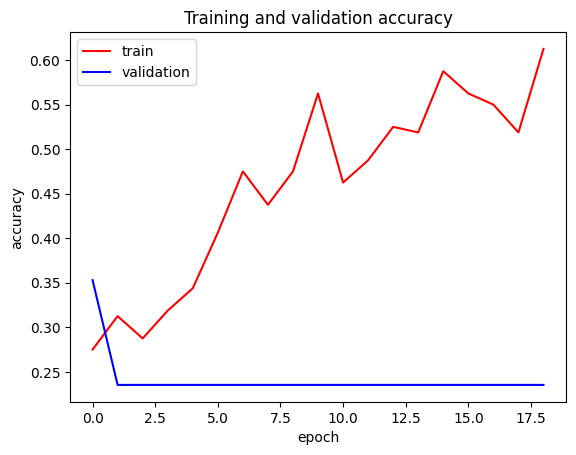

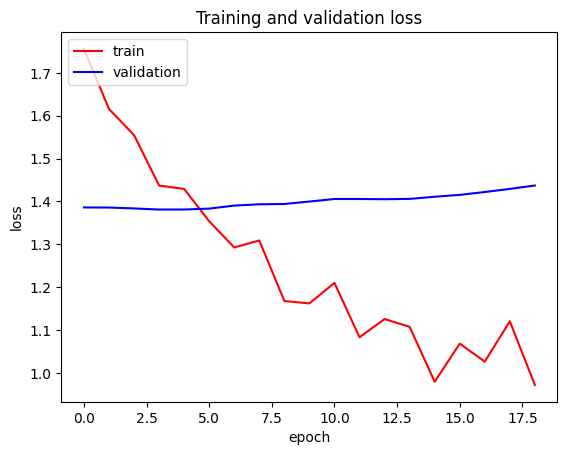

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


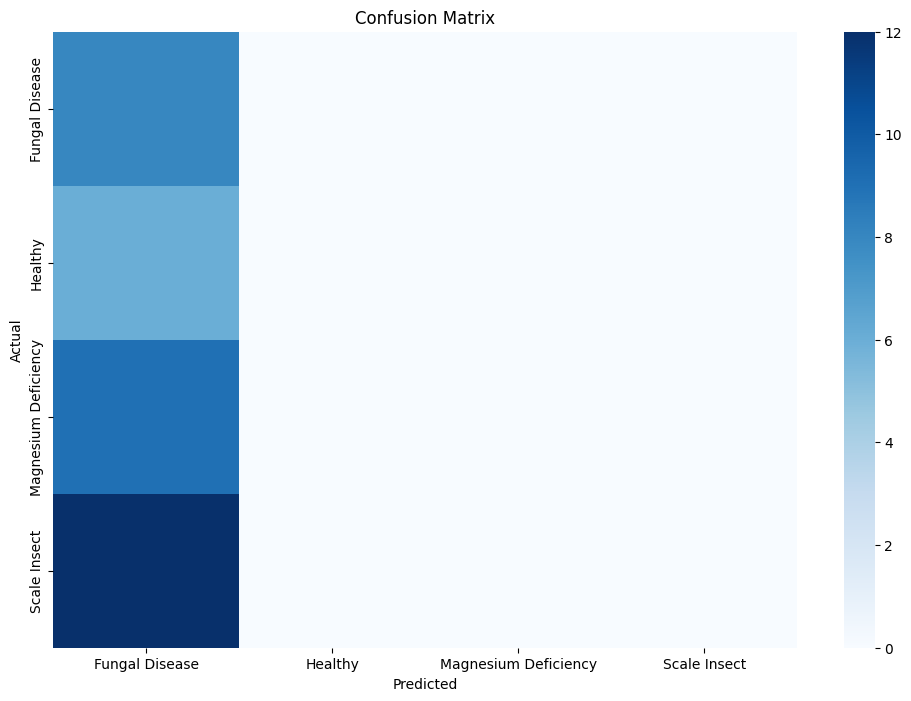

                      precision    recall  f1-score   support

      Fungal Disease       0.23      1.00      0.37         8
             Healthy       0.00      0.00      0.00         6
Magnesium Deficiency       0.00      0.00      0.00         9
        Scale Insect       0.00      0.00      0.00        12

            accuracy                           0.23        35
           macro avg       0.06      0.25      0.09        35
        weighted avg       0.05      0.23      0.09        35



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [66]:
plot_model_result(epochs, acc_1, val_acc_1, loss_1, val_loss_1)

show_model_report(model_1)

### **Evaluating Model 2**

### **Evaluating Model 3**

### **Evaluating Model Transfer Learning**

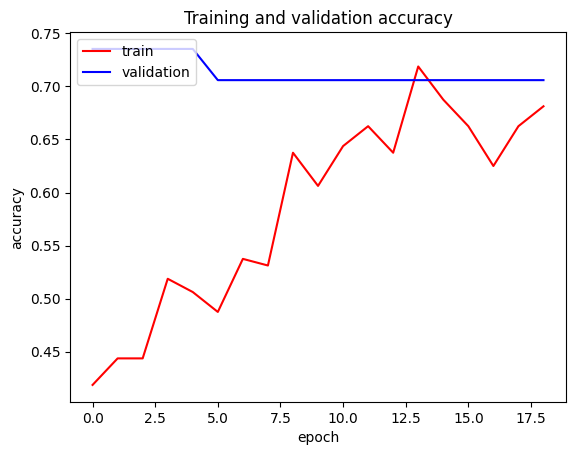

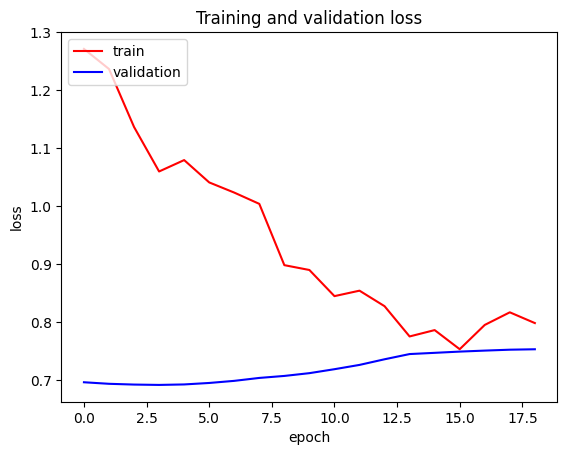

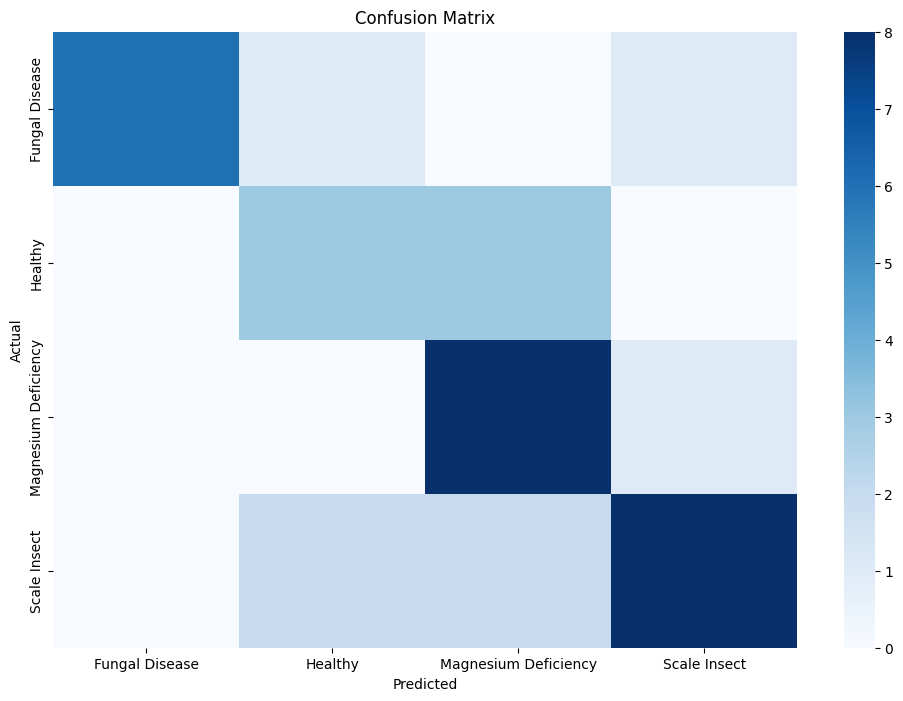

                      precision    recall  f1-score   support

      Fungal Disease       1.00      0.75      0.86         8
             Healthy       0.50      0.50      0.50         6
Magnesium Deficiency       0.62      0.89      0.73         9
        Scale Insect       0.80      0.67      0.73        12

            accuracy                           0.71        35
           macro avg       0.73      0.70      0.70        35
        weighted avg       0.75      0.71      0.72        35



In [67]:
acc_tl = history_model_tl.history['accuracy']
val_acc_tl = history_model_tl.history['val_accuracy']
loss_tl = history_model_tl.history['loss']
val_loss_tl = history_model_tl.history['val_loss']

epochs = range(len(acc_tl))

plot_model_result(epochs, acc_tl, val_acc_tl, loss_tl, val_loss_tl)

show_model_report(model_tl)

## **Converting Model**

### **Converting Model to SavedModel Format**

In [24]:
# Konversi model ke format SavedModel

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#saved_path = '/model/saved_model'

# Hapus komentar pad akode ini jika menggunakan Kaggle Notebook
saved_path = '/kaggle/working/model/saved_model'

save(model_tl, saved_path)

### **Converting SavedModel to ZIP (Kaggle Notebook)**

In [92]:
model_folder_name = "model/saved_model"
saved_model_path = "/kaggle/working/model/saved_model/"

zip_file_name = "palm-oil-model.zip"
zip_file_path = os.path.join("/kaggle", "working", zip_file_name)

if os.path.exists(saved_model_path):
    print(f"Mengkompres folder '{saved_model_path}' menjadi '{zip_file_name}'")

    working_dir = os.getcwd()
    os.chdir(saved_model_path)

    try:
        !zip -r {zip_file_name} .
        print(f"Berhasil mengkompres model ke: {zip_file_path}")

        # Membuat link download
        display(FileLink(zip_file_name))
    except Exception as e:
        print(f"Unexpected error: {e}")
    finally:
        os.chdir(working_dir)
    
else:
    print(f"Error: folder model '{model_folder_name}' tidak ditemukan di '{saved_model_path}'")

Mengkompres folder '/kaggle/working/model/saved_model/' menjadi 'palm-oil-model.zip'
  adding: variables/ (stored 0%)
  adding: variables/variables.index (deflated 78%)
  adding: variables/variables.data-00000-of-00001 (deflated 8%)
  adding: fingerprint.pb (stored 0%)
  adding: saved_model.pb (deflated 91%)
  adding: assets/ (stored 0%)
Berhasil mengkompres model ke: /kaggle/working/palm-oil-model.zip


/kaggle/working/model/saved_model/palm-oil-model.zip

## **Inferring Model**

### **Create Inference Model**

In [35]:
# Hapus komentar pada kode ini jika ingin menggunakan langsung hasil konversi
model_path = '/kaggle/working/model/saved_model'

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#model_path = 'model/saved_model'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
#model_path = "/kaggle/input/palm-oil-model/keras/default/1/saved_model"

# Load model
def load_saved_model_with_tfsm(model_path):
    if not os.path.exists(model_path):
        print(f"Error: Folder SavedModel tidak ditemukan di: {model_path}")

    loaded_model_tfsm = None
    try:
        print("Memuat model SavedModel menggunakan TFSM Layer..")
        loaded_model_tfsm = TFSMLayer(model_path, call_endpoint='serving_default')
        print("Model berhasil dimuat")

        return loaded_model_tfsm
    except Exception as e:
        print(f"Gagal memuat model SavedModel dengan TFSM layer: {e}")

# Membuat model Keras baru menggunakan layer TFSM untuk inferring
def create_model_with_tfsm(model_tfsm):
    input_layer = Input(shape=(224, 224, 3))
    output_layer = model_tfsm(input_layer)

    inference_model = Model(inputs=input_layer, outputs=output_layer)
    print("Model inferensi berhasil dibuat")
    return inference_model  

model_1_inf = load_saved_model_with_tfsm(model_path)
model_1_inf = create_model_with_tfsm(model_1_inf)

# Melihat ringkasan dari arsitektur model
model_1_inf.summary()

Memuat model SavedModel menggunakan TFSM Layer..
Model berhasil dimuat
Model inferensi berhasil dibuat


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tfsm_layer (TFSMLayer)               │ (None, 4)                   │       2,263,108 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 2,228,996 (8.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

### **Preprocessing Predict Image**

In [25]:
list_label = ['Fungal Disease','Healthy', 'Magnesium Deficiency', 'Scale Insect']

# Membuat fungsi untuk menampilkan gambar yang akan diprediski
def show_image(img_predict_path):
    img = image.load_img(img_predict_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Image Input")
    plt.show()

# Memproses gambar inputan menjadi matriks
def preprocessing_img(img_predict_path):
    img = image.load_img(img_predict_path, target_size=(224, 224))
    
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    img_tensor = tf.constant(img_array, dtype=tf.float32)

    return img_tensor

# Membuat fungsi untuk melakukan pemrosesan gambar untuk model MobileNetV2
def preprocessing_img_for_mobile_net(img_predict_path):
    img = image.load_img(img_predict_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_tensor = tf.constant(img_array, dtype=tf.float32)
    
    # processed_img = preprocess_input(img_array)
    # return processed_img
    return img_tensor
    

# Membuat fungsi untuk melakukan prediksi
def predict_img(inferring_model, img_predict_path, preprocessing_img):
    predict = inferring_model.predict(preprocessing_img(img_predict_path))

    predict_output = None

    if isinstance(predict, tuple):
        predict_output = predict['output_0']
    elif isinstance(predict, list):
        predict_output = predict[0]
    elif isinstance(predict, np.ndarray):
        predict_output = predict
            
    predicted_class = tf.argmax(predict_output, axis=1).numpy()[0]
    single_img_probably = predict_output[0]

    class_probably_list = []
    for i, prob in enumerate(single_img_probably):
        class_probably_list.append((list_label[i], prob))

    class_probably_sorted = sorted(class_probably_list, key=lambda x: x[1], reverse=True)
    for class_name, prob in class_probably_sorted:
        print(f"- {class_name}: {prob*100:.2f}%")

    predicted_class_name = class_probably_sorted[0][0]
    confidence = class_probably_sorted[0][1] * 100

    print(f"\nGambar paling cocok dengan kelas: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")

print(list_label)

['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


### **Download Predict Image from Google Drive**

In [26]:
# Mengunduh gambar prediksi dari Google Drive
file_predict_id = "1NKZ9KwIaX5OM04WnlJILV3Vm1JUfp7OL"
url_predict = f"https://drive.google.com/uc?id={file_predict_id}"
gdown.download(url_predict, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1NKZ9KwIaX5OM04WnlJILV3Vm1JUfp7OL
To: /kaggle/working/predict-img-test.zip
100%|██████████| 917k/917k [00:00<00:00, 118MB/s]


'predict-img-test.zip'

In [27]:
# Unzip berkas yang telah diunduh dari Google Drive
with zipfile.ZipFile('predict-img-test.zip', 'r') as zip_file:
    zip_file.extractall()

print("Berhasil melakukan unzip")

Berhasil melakukan unzip


### **Inferring Model**

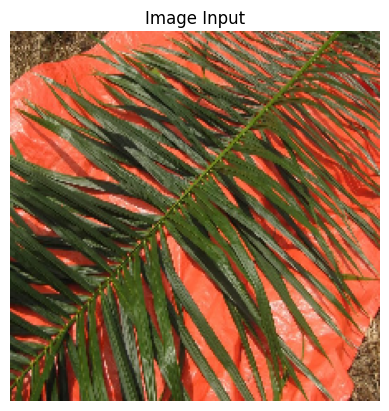

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
- Fungal Disease: 46.47%
- Magnesium Deficiency: 22.62%
- Healthy: 18.84%
- Scale Insect: 12.07%

Gambar paling cocok dengan kelas: Fungal Disease
Confidence: 46.47%


In [69]:
# Menampilkan gambar prediksi
img_predict_1 = "Predict Image Test/Healthy.png"
show_image(img_predict_1)

# Melakukan prediksi
predict_result_1 = predict_img(model_tl, img_predict_1, preprocessing_img_for_mobile_net)

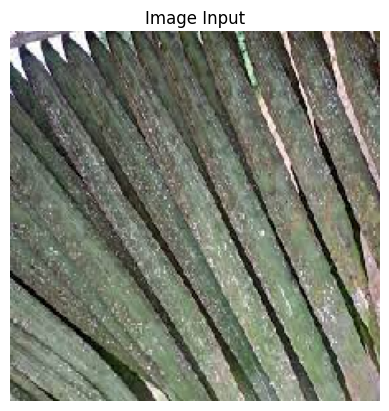

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
- Magnesium Deficiency: 45.31%
- Fungal Disease: 26.00%
- Healthy: 24.36%
- Scale Insect: 4.33%

Gambar paling cocok dengan kelas: Magnesium Deficiency
Confidence: 45.31%


In [70]:
# Menampilkan gambar prediksi
img_predict_2 = "Predict Image Test/Fungal Disease.jpeg"
show_image(img_predict_2)

# Melakukan prediksi
predict_result_2 = predict_img(model_tl, img_predict_2, preprocessing_img_for_mobile_net)

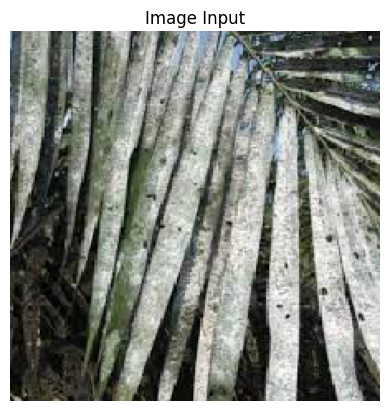

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
- Healthy: 58.30%
- Fungal Disease: 23.77%
- Magnesium Deficiency: 15.55%
- Scale Insect: 2.37%

Gambar paling cocok dengan kelas: Healthy
Confidence: 58.30%


In [71]:
# Menampilkan gambar prediksi
img_predict_3 = "Predict Image Test/Scale Insect.jpeg"
show_image(img_predict_3)

# Melakukan prediksi
predict_result_3 = predict_img(model_tl, img_predict_3, preprocessing_img_for_mobile_net)

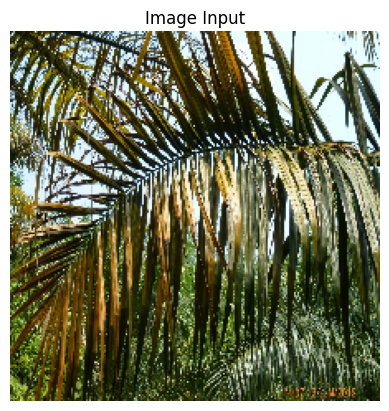

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
- Magnesium Deficiency: 59.71%
- Healthy: 37.80%
- Fungal Disease: 1.34%
- Scale Insect: 1.16%

Gambar paling cocok dengan kelas: Magnesium Deficiency
Confidence: 59.71%


In [72]:
# Menampilkan gambar prediksi
img_predict_4 = "Predict Image Test/Magnesium Deficiency.jpg"
show_image(img_predict_4)

# Melakukan prediksi
predict_result_4 = predict_img(model_tl, img_predict_4, preprocessing_img_for_mobile_net)